In [1]:
import sklearn

print(sklearn.__version__)

1.7.2


In [7]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier  #sklearn.tree 모든 tree 기반 ml알고리즘 구현
from sklearn.model_selection import train_test_split # sklearn.model_selection  데이터분리, 알고리즘 평가


import pandas as pd
iris =load_iris()

# 피쳐데이터
iris_data=iris.data

#타겟데이터
iris_label =iris.target

#데이터 프레임으로 변환
iris_df=pd.DataFrame(iris_data,columns=iris.feature_names)
iris_df['label']=iris_label

iris_df.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


In [34]:
X_train,X_test,y_train,y_test=train_test_split(iris_data,iris_label, test_size=0.2, random_state=11)
# iris_data,iris_label은 넘파이의형태임

#객체 생성
df_clf=DecisionTreeClassifier(random_state=11)

#학습 수행
df_clf.fit(X_train,y_train)

#예측 수행 , 테스트 데이터로
pred=df_clf.predict(X_test)

#예측의 결과물에 대한 성능 평가
from sklearn.metrics import accuracy_score

print('정확도:', accuracy_score(y_test,pred))


#데이터를 학습데이터와 훈련데이터로 분리함 train_test_split()
#ml알고리즘 객체를 불런호 학습수행 model=~ , model.fit
#학습된 모델로 예측을 한다 model.predict(x_test)
#모델의 성능을 평가한다  성능지표함수(y_test,pred)


정확도: 0.9333333333333333


In [32]:
#import numpy as np
#피처=iris_df.to_numpy()[:,:-1]  # np.array(df) , 특정칼럼부터 특정칼럼? loc[:,칼럼명:칼럼명]
#타겟=iris_df.to_numpy()[:,-1]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.])

In [ ]:
# 분류 알고리즘 classifier + 회귀알고리즘 regressor =estimator  = 지도알고리즘
# cross_val_score() 같은 evlaudation 함수, GridSearchCV같은 하이퍼파라미터 튜닝 지원 클래스는 모두 Estimator을 인자로 받는다
# 즉 estimator의 fit,predict 메서드를 이용해서  score를 내거나 하이퍼파라미터튜닝하는것

#비지도 학습 차원축소, 피처추출, 클러스터링 대부분 fit과 transfomr을 적용 fit은 학습이 아닌 fit으로 데이터 구조를 변환하고 transform으로 실제 작업을 진행

In [48]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
import numpy as np

iris=load_iris()
features=iris.data
label=iris.target

dt_clf=DecisionTreeClassifier(random_state=156)

#5개의 폴드 세트로 분리하는 kfold객체와 폴드 세트별 정확도를담을 리스트 객체를 생성
kfold=KFold(n_splits=5)
cv_accuracy=[]
print(features.shape[0])


n_iter=0
#kfold 객체의 split을 이용해 데이터를 fold로 분리함 , 또한 훈련과 검증데이터의 인덱스도 반환함

for train_index,test_index in kfold.split(features):
    # split으로 반환된 인덱스를 이용해 학습용 ,검증용 데이터 추출
    X_train,X_test = features[train_index],features[test_index]
    y_train,y_test= label[train_index],label[test_index]

    # 학습 및 예측
    dt_clf.fit(X_train,y_train)
    pred=dt_clf.predict(X_test)
    n_iter+=1

    # 반복시마다 측정
    accuracy= np.round(accuracy_score(y_test,pred),4)
    print(f'교차검증 정확도 {accuracy}')
    print(f'검증세트 인덱스 {n_iter},{test_index}')
    cv_accuracy.append(accuracy)

print(np.mean(cv_accuracy))





150
교차검증 정확도 1.0
검증세트 인덱스 1,[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]
교차검증 정확도 0.9667
검증세트 인덱스 2,[30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53
 54 55 56 57 58 59]
교차검증 정확도 0.8667
검증세트 인덱스 3,[60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83
 84 85 86 87 88 89]
교차검증 정확도 0.9333
검증세트 인덱스 4,[ 90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119]
교차검증 정확도 0.7333
검증세트 인덱스 5,[120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137
 138 139 140 141 142 143 144 145 146 147 148 149]
0.9


In [6]:
# kfold 작동원리

from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['label']=iris.target
iris_df['label'].value_counts()

label
0    50
1    50
2    50
Name: count, dtype: int64

In [7]:
from sklearn.model_selection import KFold

kfold = KFold(n_splits=3)

n_iter=0
for train_index,test_index in kfold.split(iris_df):
    n_iter+=1
    label_train = iris_df['label'].iloc[train_index]
    label_test  = iris_df['label'].iloc[test_index]
    print(f'교차검증{n_iter}')
    print(f'학습 레이블 데이터분포, {label_train.value_counts()}')
    print(f'테스트 레이블 데이터분포, {label_test.value_counts()}')

교차검증1
학습 레이블 데이터분포, label
1    50
2    50
Name: count, dtype: int64
테스트 레이블 데이터분포, label
0    50
Name: count, dtype: int64
교차검증2
학습 레이블 데이터분포, label
0    50
2    50
Name: count, dtype: int64
테스트 레이블 데이터분포, label
1    50
Name: count, dtype: int64
교차검증3
학습 레이블 데이터분포, label
0    50
1    50
Name: count, dtype: int64
테스트 레이블 데이터분포, label
2    50
Name: count, dtype: int64


In [8]:
# stratifiedkfold
# 일반적으로 분류에서는 교차 검증은 kfold가 아닌 stratifiedkfold사용해야함
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

dt_clf = DecisionTreeClassifier(random_state=156)

features = iris.data
label = iris.target


skfold = StratifiedKFold(n_splits=3)
n_iter = 0
cv_accuracy = []

for train_index, test_index in skfold.split(features, label):
    X_train, X_test = features[train_index], features[test_index]
    y_train, y_test = label[train_index], label[test_index]

    # 학습 및 예측
    dt_clf.fit(X_train, y_train)
    pred = dt_clf.predict(X_test)

    n_iter += 1
    accuracy = np.round(accuracy_score(y_test, pred), 4)
    cv_accuracy.append(accuracy)

print(cv_accuracy)
print(np.round(np.mean(cv_accuracy), 4))

[0.98, 0.94, 0.98]
0.9667


# 교차검증 api

In [9]:
# cross_val_score()
#cross_val_score(estimator,X,y=none, scoring=None , cv =None, n_jobs=1, verbose = 0 , fit_arams=None,pre_dispatch='2*n_jobs')
# estimator , X,y  ,scoring , cv 
#cross_val_score는 estimator에 분류모델이 들어가면 자동으로 stratifiedkfold를 사용함, 회귀는 단순 kfold


from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.datasets import load_iris

iris_data=load_iris()
feature = iris_data.data
label = iris_data.target

dt_clf=DecisionTreeClassifier(random_state=156)


#성능 지표는 정확도, 교차 ㄱㅁ증 세트는 3개

score = cross_val_score(dt_clf,X=feature, y=label,scoring='accuracy',cv=3)
print(score)
print(np.mean(score))

# cross_val_score 내부의 estimator 의 api가 자동으로 fit,predict,평가를 다해줌 
# cross_val_validate 비슷함, 수행 시간도 같이 제공함 

[0.98 0.94 0.98]
0.9666666666666667


In [10]:
#GridSearchCV- 교차검증과 최적 하이퍼 파라미터 튜닝을 한번에 하기 

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

# 데이터를 로딩하고 학습 데이터와 테스트 데이터 분리

iris_data = load_iris()

X_train,X_test,y_train,y_test = train_test_split(iris_data.data , iris_data.target,
                                                 test_size=0.2, random_state=121)


dtree=DecisionTreeClassifier()

#파라미터를 사전형으로 저장
parameters = {'max_depth':[1,2,3], 'min_samples_split':[2,3]}

# param_grid에 입력된 파라미터의 조합에 따라 gridsearchcv가 내부에서 데이터를 train,test,검증폴드로 나눠서 scoring을 수행함
grid_dtree=GridSearchCV(dtree,param_grid=parameters,cv=3,refit=True)

#붗꽃 학습 데이터로 param_grid의 하이퍼 파라미터를 순차적으로 학습 평가
grid_dtree.fit(X_train,y_train)

score_df=pd.DataFrame(grid_dtree.cv_results_)  ## .cv_results_
print(score_df[['params','mean_test_score','rank_test_score','split0_test_score','split1_test_score','split2_test_score']])



print(f'최적 파라미터{grid_dtree.best_params_}')
print(f'최고 정확도 {grid_dtree.best_score_}')


                                     params  mean_test_score  rank_test_score  \
0  {'max_depth': 1, 'min_samples_split': 2}         0.700000                5   
1  {'max_depth': 1, 'min_samples_split': 3}         0.700000                5   
2  {'max_depth': 2, 'min_samples_split': 2}         0.958333                3   
3  {'max_depth': 2, 'min_samples_split': 3}         0.958333                3   
4  {'max_depth': 3, 'min_samples_split': 2}         0.975000                1   
5  {'max_depth': 3, 'min_samples_split': 3}         0.975000                1   

   split0_test_score  split1_test_score  split2_test_score  
0              0.700                0.7               0.70  
1              0.700                0.7               0.70  
2              0.925                1.0               0.95  
3              0.925                1.0               0.95  
4              0.975                1.0               0.95  
5              0.975                1.0               0.95  
최적 파라

In [11]:
# refit=True이면 gridsearchcv가 최적의 성능을 나타내는 파라미터로 estimaotr를 학습해 best_estimator_로 저장해 놓음

# gridsearcgcv가 refit으로 이미 학습된 estimator_를 반환
estimator=grid_dtree.best_estimator_

# 학습이 되엇으니 별도학습 x 바로 예측
pred=estimator.predict(X_test)
print(f'{accuracy_score(y_test,pred)}')



#GridSearchCV도 cross_val_score처럼 내부에서 fold를 나누고 학습·예측·평가를 하지만, 
#그 검증 결과는 하이퍼파라미터 선택에 사용된 점수이므로 최종 성능 평가용 test set은 따로 분리하는 것이 좋습니다.
# cross_Val_score는 단순 모델평가를 위함이라 내부에서 알아서 train,test,split이 일어남
# 반면 그리드서치는 최종 성능평가를 위해 따로 모델의 학습에 사용되지 않은 test 데이터셋을 빼놓는 의미가 있음 

0.9666666666666667


# 데이터 전처리

* 결측치 처리 아예 drop, 평균값,  등등..
* 문자열 값(카테고리형 피처 ,텍스트형 피처 -> 순서같은 건 있을수 있어도 크기의 중요성이 없음) 처리 벡터화, 삭제 ex 주민번호는 문자열인거지

In [12]:
# 레이블 인코딩 , 원-핫 인코딩 

from sklearn.preprocessing import LabelEncoder

items=['tv','냉장고','전자레인지','컴퓨터','선풍기','선풍기','믹서','믹서']


#labelEncoder를 객체로 생성 후 , fit()과 transform으로 레이블 인코딩 수행중

encoder= LabelEncoder()
encoder.fit(items)
labels=encoder.transform(items)
print(labels)
print(encoder.classes_)
# but, 숫자 변환 값은 단순 코드이기 때문에 크기나 순서 중요도로 언급되어선 안됨 특히 선형회귀 ml에서는 안됨 , 트리 계열이면 상관 x

[0 1 4 5 3 3 2 2]
['tv' '냉장고' '믹서' '선풍기' '전자레인지' '컴퓨터']


In [13]:
# 원핫 인코딩
# 입력값으로 2차원데이터가 필요함 , 변환 값이 희소행렬형태라 , 다시 toarray()메서드로 밀집행렬(dense)행렬로 변환해야한다 .

from sklearn.preprocessing import OneHotEncoder
import numpy as np

items=['tv','냉장고','전자레인지','컴퓨터','선풍기','선풍기','믹서','믹서']


#2차원 ndarray로 변환하기
items=np.array(items).reshape(-1,1)
print(items)

# 원-핫인코딩 적용하기
oh_encoder=OneHotEncoder()
oh_encoder.fit(items)
oh_labels=oh_encoder.transform(items)

#toarray로 밀집행렬로 변환하기

print(oh_labels.toarray())

[['tv']
 ['냉장고']
 ['전자레인지']
 ['컴퓨터']
 ['선풍기']
 ['선풍기']
 ['믹서']
 ['믹서']]
[[1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]]


In [71]:
# get_dummies()
# pd.get_dummies(데이터프레임df, columns=['상품'] or 시리즈) => 바로 형변환이됨  데이터프레임을 넣거나 시리즈 넣거나 데이터프레임에서 일부 칼럼만변형하거나

In [ ]:
# 피쳐스케일링과 정규화

# 표준화(평균 0 , 분산1 ,  정규분포의 형태를 띄도록 데이터를 변환)
# 정규화(서로 다른 피처의 크기를 통일 시키는 것 단위 통일이라고 보면됨ㅇㅇ)

# standardsclaer(표준화)  # 특히 서포트벡터머신, 선형회귀 ,로지스틱 회귀의 경우 데이터가 가우시안 정규분포를 따른다는 가정이 있기 때문임
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
iris_data=iris.data
iris_df=pd.DataFrame(data=iris_data,columns=iris.feature_names)

print(iris_df.mean(),iris_df.var())


from sklearn.preprocessing import StandardScaler

#스케일러 객체 생성
scaler =StandardScaler()
#fit,transform 호출
scaler.fit(iris_df)
scalerd_iris=scaler.transform(iris_df)

iris_df_scalerd=pd.DataFrame(data=scalerd_iris,columns=iris.feature_names)


sepal length (cm)    5.843333
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199333
dtype: float64 sepal length (cm)    0.685694
sepal width (cm)     0.189979
petal length (cm)    3.116278
petal width (cm)     0.581006
dtype: float64


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()
scaler.fit(iris_df)
iris_scaled=scaler.transform(iris_df)

# 주의점
# scaler객체 생성 후 fit은 데이터 변환을 위한 기준을 설정, transform은 설정된 정보를 이용해 데이터를 변환
# 다만, 훈련데이터로 fit과 transform을 진행한다면 테스트 데이터로는 fit을 진행하지않고 transform만진행함 

scaler=MinMaxScaler()
scaler.fit(train_array)
train_array_scaled=scaler.transform(train_array)
test_array_scaled=scaler.transfomr(test_array)


# 가능하다면 전체 데이터의 스케일링을 변환을 적용한뒤 학습과 테스트 데이터로 분리 , 여의치 않으면 테스트 변환시에는 fit을 적용하지 않기



NameError: name 'train_array' is not defined

In [50]:
# 06 타이타닉 생존자 예측

import pandas as pd 
import numpy as  np
import matplotlib as plt
import seaborn as sns

titanic_df=pd.read_csv('titanic_train.csv')
titanic_df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [51]:
print('\n ## 학습데이터 정보 ##')
print(titanic_df.info())


 ## 학습데이터 정보 ##
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [52]:
## 1.총 행은 891인데.. age, cabin, embarked의 null값을 어떻게 처리할 것인가?
#예제에서는 나이만 평균, 나머지는 N으로 채우기로함
titanic_df['Age'].fillna(titanic_df['Age'].mean(),inplace=True)
titanic_df['Cabin'].fillna('N',inplace=True)
titanic_df['Embarked'].fillna('N',inplace=True)
print(titanic_df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


C:\Users\rhals\AppData\Local\Temp\ipykernel_28180\1787957321.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df['Age'].fillna(titanic_df['Age'].mean(),inplace=True)
C:\Users\rhals\AppData\Local\Temp\ipykernel_28180\1787957321.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a

In [53]:
## 2.머신러닝을 적용하기위해선 문자열 피쳐가 숫자로 바꿔야함
# name,ticket을 신경쓰지 않는 이유가뭘가? 범주형 변수로 바꿔서 모델에 넣을 수 있는가? 형식이 제각각이라 일반화가 어려워서? 가능은한데 초급 전처리에서는 신경안씀
# 그래서 sex, cabin,embarked만..

print(titanic_df['Sex'].value_counts())
print(titanic_df['Cabin'].value_counts())
print(titanic_df['Embarked'].value_counts())

Sex
male      577
female    314
Name: count, dtype: int64
Cabin
N              687
C23 C25 C27      4
G6               4
B96 B98          4
C22 C26          3
              ... 
E34              1
C7               1
C54              1
E36              1
C148             1
Name: count, Length: 148, dtype: int64
Embarked
S    644
C    168
Q     77
N      2
Name: count, dtype: int64


In [54]:
# sex,embarked는 괜찮아 보이나 cabin의 경우는 추가 전처리가 필요해보임 # ticket이나 name같은경우는 일반화가 쉽게안되고 전부다 고유함..
# 1. 여러 cabin이 한꺼번에 입력된 경우가 있음 2.도메인 관점으로 탑승위치나 객실구역의 등급이 생존과 관련있을 수 있음 3.데이터 관점으로 보면 , 범주형변수로 일반화가능함

titanic_df['Cabin']=titanic_df['Cabin'].str[:1]
print(titanic_df['Cabin'].head(3))

0    N
1    C
2    N
Name: Cabin, dtype: object


In [55]:
# 전처리후 EDA 
# 각 변수들이 종속변수와 어떤 관계가 있는지, 그리고 모델에 넣어도 되는 형태인지 확인하기
# TITANIC예제에서는 어떤 특성(독립변수)를 가진 승객이 생존할 가능성이 높은가?라는 질문을 기준으로 변수를 본다


#EDA1. 성별에 따른 생존률
titanic_df.groupby(['Sex','Survived'])['Survived'].count()


Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

<Axes: xlabel='Sex', ylabel='Survived'>

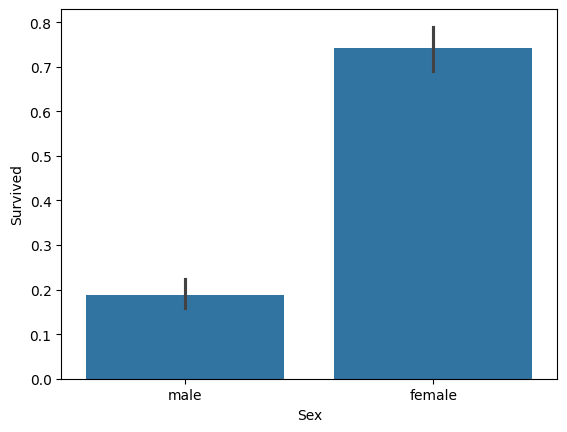

In [56]:
sns.barplot(x='Sex',y='Survived',data=titanic_df)

In [57]:
# eda02 부자와 가난한 사람 사이의 생존률

titanic_df.groupby(['Pclass','Survived'])['Survived'].count()

Pclass  Survived
1       0            80
        1           136
2       0            97
        1            87
3       0           372
        1           119
Name: Survived, dtype: int64

<Axes: xlabel='Pclass', ylabel='Survived'>

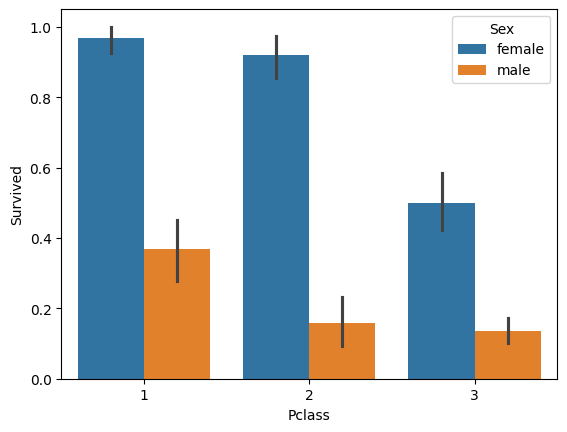

In [58]:
sns.barplot(x='Pclass',y='Survived',hue='Sex',data=titanic_df)
# 1,2등석의 경우 차이가 없으나(기본적으로 여성이 더 생존가능성이 높음), 3등석의 경우 여성의 생존가능성 또한 떨어짐
# 남성의 경우 1등성의 생존가능성이 2,3등석보다 훨씬높음

In [59]:
#eda03 나이에 따른 생존가능성
#age 범위가 넓기 때문에, apply lambda 식을 이용해서 범위별로 분류하기로함

def get_category(age):
    cat=''
    if age<=-1: cat='Unknown'
    elif age<=5: cat ='Baby'
    elif age<=12: cat ='Child'
    elif age<=18: cat ='Teenager'
    elif age<=25: cat ='Student'
    elif age<=35: cat ='Young Adult'
    elif age<=60: cat ='Adult'
    else : cat ='Elderly'

    return cat

titanic_df['Age_cat']=titanic_df['Age'].apply(lambda x: get_category(x))

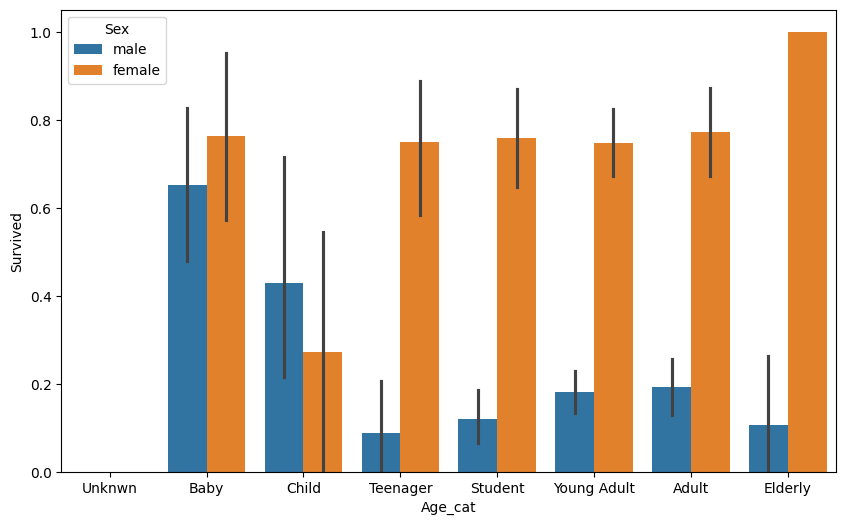

In [ ]:
import matplotlib.pyplot as plt
# 막대그래프의 크기 figure설정
plt.figure(figsize=(10,6))

#x축값을 순차적으로 표시하기 위한 설정
group_names=['Unknwn','Baby','Child','Teenager','Student','Young Adult','Adult','Elderly']

#그래프 만들기
sns.barplot(x='Age_cat',y='Survived',hue='Sex',data=titanic_df,order=group_names)
plt.show()
titanic_df.drop('Age_cat',axis=1,inplace=True) # axis=0은 행을지우고 axis=1 은 칼럼을지움


# 해석 
# 1.baby의 생존률은 대단히높음수준 2.child부분에서 여자아이의 생존률이 낮은 편 정도?
# 중요한 피처가 성별, plcass, age라는것정도?

In [ ]:
# eda의 역할 1. 도메인 관점 2. 데이터 관점에서 특정 변수가 종속변수에 영향을 미치는지 확인
# 도메인관점으로 생각해본후, 데이터 관점에서 차이가 진짜 있는지 확인 => 쓸만한 변수 후보  즉 eda는 모델링 후보를 정하는 것
# 데이터 관점에서 진짜 차이가 있다고하더라도 변수 간 관계를 봐야함, 그 변수 자체가 아니라 다른 변수와 섞여서 보일 수 있기 때문
# 이후 모델링 관점에서 인코딩 가능성, 범주 수 이상치 분포같은 것을 보는 것

도메인 관점으로 가설 설정
↓
데이터 관점으로 생존율 차이 확인
↓
변수 간 관계 확인
↓
그 차이가 진짜 쓸 만한 신호인지 판단
↓
모델링 후보로 사용  사용후에 성능이 좋아지는지 검증함.

따라서 eda으 ㅣ목적은 
어떤 변수를 쓸지
어떤 변수를 가공할지
어떤 변수를 조심해서 해석할지
어떤 모델 구조가 적절할지 생각해보는것  

In [ ]:
# 문자열 카테고리 피처를 숫자형 카테고리로 cabin이나 embarked같은경우는 예제의 단순화를 위해 원핫이 아닌 라벨인코딩ㅇ.

from sklearn.preprocessing import LabelEncoder

def encode_feature(dataDF):
    feature= ['Cabin','Sex','Embarked']
    for i in feature:
        Ll=LabelEncoder()
        Ll.fit(dataDF[i])
        dataDF[i]=Ll.transform(dataDF[i])
    return dataDF


titanic_df=encode_feature(titanic_df)
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,7,3
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,2,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,7,3
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,2,3
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,7,3


In [63]:
# 전체 전처리 함수 

#null 처리 함수
def fillna(df):
    df['Age'].fillna(df['Age'].mean(),inplace=True)
    df['Cabin'].fillna('N',inplace=True)
    df['Embarked'].fillna('N',inplace=True)
    df['Fare'].fillna(0,inplace=True)
    return df

#머신러닝 알고리즘에서 불필요한 피처제거
def drop_feature(df):
    df.drop(['PassengerId','Name','Ticket'],axis=1,inplace=True)
    return df

#레이블인코딩

def format_feature(df):
    df['Cabin']=df['Cabin'].str[:1]
    feature= ['Cabin','Sex','Embarked']
    for i in feature:
        Ll=LabelEncoder()
        Ll.fit(df[i])
        df[i]=Ll.transform(df[i])
    return df

#전처리 함수 호출

def total_transform_feature(df):
    df=fillna(df)
    df=drop_feature(df)
    df=format_feature(df)
    return df
    

In [ ]:
#원본데이터 로딩, 피처 데이터 세트와 레이블 데이터 세트 추출 및 total 전처리 완료

titanic_df=pd.read_csv('titanic_train.csv')
y_titanic_df=titanic_df['Survived']
x_titainc_df=titanic_df.drop('Survived',axis=1)

x_titainc_df=total_transform_feature(x_titainc_df)

C:\Users\rhals\AppData\Local\Temp\ipykernel_28180\4145153940.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)
C:\Users\rhals\AppData\Local\Temp\ipykernel_28180\4145153940.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

In [65]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(x_titainc_df,y_titanic_df,test_size=0.2,random_state=11)

In [72]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 모델 객체 생성
dt=DecisionTreeClassifier(random_state=11)
rf=RandomForestClassifier(random_state=11)
lr=LogisticRegression(solver='liblinear')

#dt 의fit 과 predict
dt.fit(X_train,y_train)
dt_pred=dt.predict(X_test)
print('dt정확도 :',accuracy_score(y_test,dt_pred))

#rl의 fit과 predict
rf.fit(X_train,y_train)
rf_pred=rf.predict(X_test)
print('rf정확도 :',accuracy_score(y_test,rf_pred))

#lr의 fit과 predict
lr.fit(X_train,y_train)
lr_pred=lr.predict(X_test)
print('lr정확도 :',accuracy_score(y_test,lr_pred))

dt정확도 : 0.7877094972067039
rf정확도 : 0.8547486033519553
lr정확도 : 0.8659217877094972


In [ ]:
# 번외 kfold와 enumerate 

# from sklearn.model_selection import KFold
# import numpy as np

# X = np.arange(10)
# 1~9까지 숫자가 x라고할때 폴드 5개로 분리
# kfold = KFold(n_splits=5)

# for train_index, test_index in kfold.split(X):
#     print(train_index, test_index)

# [2 3 4 5 6 7 8 9] [0 1]
# [0 1 4 5 6 7 8 9] [2 3]
# [0 1 2 3 6 7 8 9] [4 5]
# [0 1 2 3 4 5 8 9] [6 7]
# [0 1 2 3 4 5 6 7] [8 9]


# for fold_idx, (train_index, test_index) in enumerate(kfold.split(X)):
#     print(fold_idx)
#     print("train:", train_index)
#     print("test:", test_index)

# 0
# train: [2 3 4 5 6 7 8 9]
# test: [0 1]

# 1
# train: [0 1 4 5 6 7 8 9]
# test: [2 3]

# 2
# train: [0 1 2 3 6 7 8 9]
# test: [4 5]
# ...

In [76]:
# 교차검증 kfold

from sklearn.model_selection import KFold

def ex_kfold(clf,folds=5):
    kfold=KFold(n_splits=folds)
    scores=[]

    for fold_idx,(train_index,test_index) in enumerate(kfold.split(x_titainc_df)):
        X_train,X_test=x_titainc_df.values[train_index],x_titainc_df.values[test_index]
        y_train,y_test=y_titanic_df.values[train_index],y_titanic_df.values[test_index]

        #clf학습
        dt.fit(X_train,y_train)
        #예측
        prediction=dt.predict(X_test)
        accuracy=accuracy_score(y_test,prediction)
        scores.append(accuracy)
        print(f'교차검증 정확도{accuracy}, 폴드수{fold_idx}')
    
    # 5개폴드의 평균값 계산
    print(np.mean(scores))

#kfold호출
ex_kfold(dt,folds=5)

교차검증 정확도0.7541899441340782, 폴드수0
교차검증 정확도0.7808988764044944, 폴드수1
교차검증 정확도0.7865168539325843, 폴드수2
교차검증 정확도0.7696629213483146, 폴드수3
교차검증 정확도0.8202247191011236, 폴드수4
0.782298662984119


In [79]:
from sklearn.model_selection import cross_val_score

scores=cross_val_score(dt,x_titainc_df,y_titanic_df,cv=5)
print(scores)
print(np.mean(scores))
# 값이 다른이유는 cross_val_score가 분류모델의 경우 stratifiedkfold를진행하기때문임

[0.74301676 0.7752809  0.79213483 0.78651685 0.84269663]
0.7879291946519366


In [ ]:
from sklearn.model_selection import GridSearchCV

parameters={'max_depth':[2,3,5,10]
            ,'min_samples_split':[2,3,5],'min_samples_leaf':[1,5,8]}

grid_dt=GridSearchCV(dt,param_grid=parameters,scoring='accuracy',cv=5)
grid_dt.fit(X_train,y_train)


#그리드서치는 자동으로 best_params_, best_score_를 저장함 , 그런 최적의 성능을 나타내ㅡㄴ 하이퍼 파라미터로 estimotor를 학습해 
#best_estimor_로 저장해놓음
print('최적의파라미터:',grid_dt.best_params_)
print('최고점수:',grid_dt.best_score_)

#최적의 하이퍼파라미터로 저장된 정보가 estimator로 학습
best_dt=grid_dt.best_estimator_
# 최적의 하이퍼파라미터로 저장된 estimator로 예측
dt_pred_best_dt=best_dt.predict(X_test)
print('하이퍼파라미터 튜닝후 테스트에서의 최고 accuracy',accuracy_score(y_test,dt_pred_best_dt))

#왜 최고점수가 위아래 다름? 위에 gridserch는 폴드를 train데이터를 fold로구분해서 만든 최고점수고
#거기서 찾은 하이퍼파라미터를 이용해서 X_test데이터를 이용해 y_test데이터로 일반화한 값을 비교한거임
#즉 학습한 뒤에 별도의 테스트 데이터 세트로 평가한거임


최적의파라미터: {'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}
최고점수: 0.7991825076332119
하이퍼파라미터 튜닝후 테스트에서의 최고 accuracy 0.8715083798882681
